In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
df=pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [4]:
df.shape

(545, 13)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


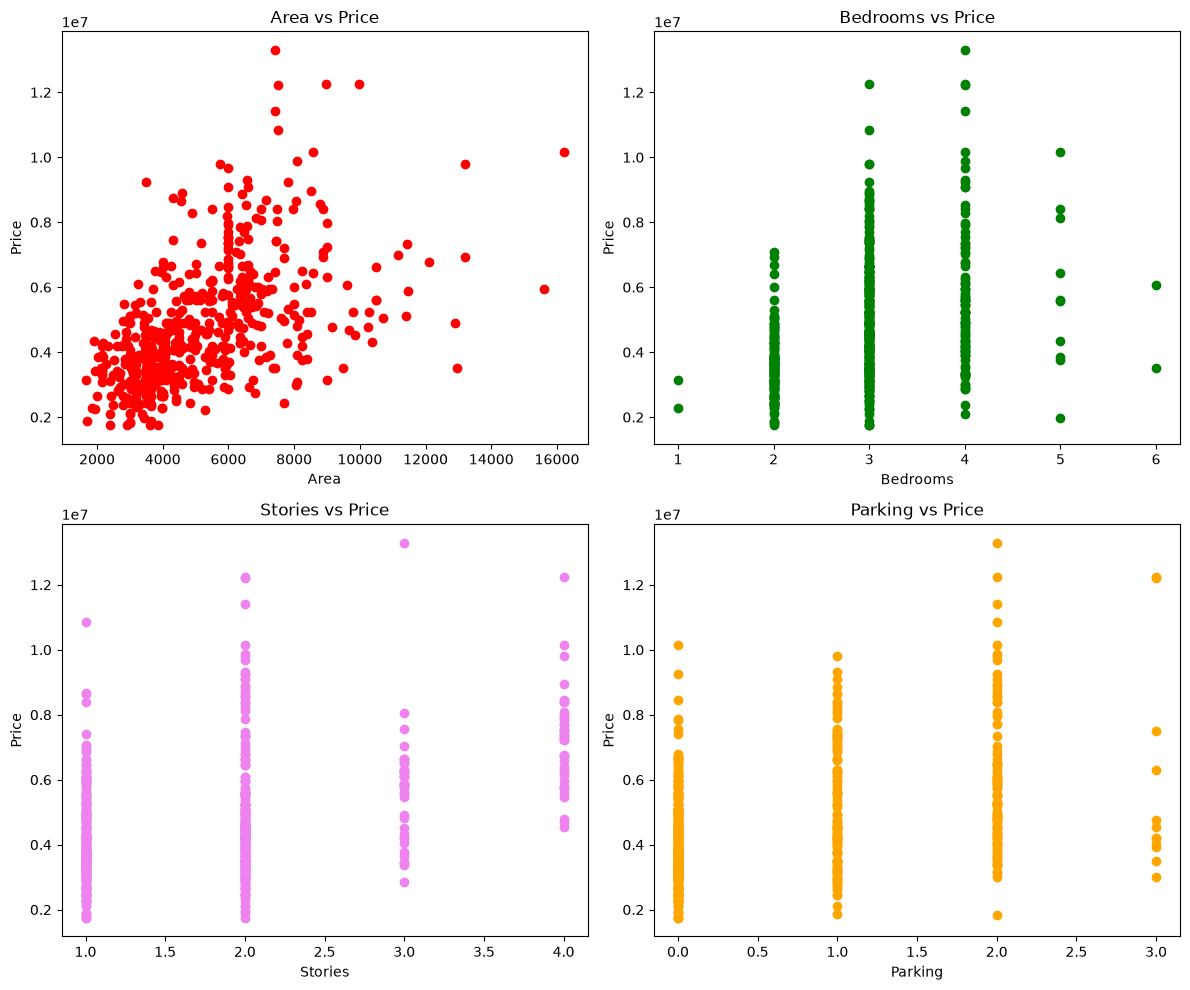

In [6]:
fig,axes=plt.subplots(2,2,figsize=(12,10))

axes[0,0].scatter(df['area'],df['price'],color="red")
axes[0,0].set_xlabel('Area')
axes[0,0].set_ylabel('Price')
axes[0,0].set_title('Area vs Price')

axes[0,1].scatter(df['bedrooms'],df['price'],color="green")
axes[0,1].set_xlabel('Bedrooms')
axes[0,1].set_ylabel('Price')
axes[0,1].set_title('Bedrooms vs Price')

axes[1,0].scatter(df['stories'],df['price'],color="violet")
axes[1,0].set_xlabel('Stories')
axes[1,0].set_ylabel('Price')
axes[1,0].set_title('Stories vs Price')

axes[1,1].scatter(df['parking'],df['price'],color="orange")
axes[1,1].set_xlabel('Parking')
axes[1,1].set_ylabel('Price')
axes[1,1].set_title('Parking vs Price')

plt.tight_layout()
plt.show()

In [7]:
binary_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]
for col in binary_columns:
    df[col]=df[col].map({'yes':1,'no':0})

In [8]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [9]:
df = pd.get_dummies(df,
                    columns=['furnishingstatus'],
                    drop_first=True)



print(df.dtypes)

price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object


In [10]:
df['furnishingstatus_semi-furnished']=df['furnishingstatus_semi-furnished'].astype(int)
df['furnishingstatus_unfurnished'] = df['furnishingstatus_unfurnished'].astype(int)

In [11]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [12]:
x=df.drop('price',axis=1)
y=df["price"]
print(x)
print("*"*50)
print(y)

     area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0    7420         4          2        3         1          0         0   
1    8960         4          4        4         1          0         0   
2    9960         3          2        2         1          0         1   
3    7500         4          2        2         1          0         1   
4    7420         4          1        2         1          1         1   
..    ...       ...        ...      ...       ...        ...       ...   
540  3000         2          1        1         1          0         1   
541  2400         3          1        1         0          0         0   
542  3620         2          1        1         1          0         0   
543  2910         3          1        1         0          0         0   
544  3850         3          1        2         1          0         0   

     hotwaterheating  airconditioning  parking  prefarea  \
0                  0                1        2     

In [13]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
print("train shape:",x.shape)
print("test shape:",y.shape)

train shape: (545, 13)
test shape: (545,)


In [14]:
model=RandomForestRegressor()
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [15]:
y_pred=model.predict(x_test)
print(y_pred)

[ 5395180.          7282240.          3803730.          4433170.
  3712100.          3525970.          5070100.          5198550.
  2646700.          2855359.5        10055109.4         3280830.
  2944007.5         3430280.          3630112.5         4287500.
  3273525.5         5053300.          3729810.          4065775.
  5552015.          5932850.          3015436.66666667  3533740.
  4605440.          6702045.          3235190.          4824120.
  6448190.          3336200.          5553170.          3144330.
  6704069.4         4242280.          3061520.          6347740.
  4720240.          3658095.          2986200.          4159400.
  4056010.          2780499.16666667  7519540.          4178790.
  4099270.          4168780.          7338619.4         4078970.
  2845780.          3054240.          8105073.2         2553740.
  4209310.          4609640.          3307360.          2852528.
  6958840.          2972238.5         5056240.          3122087.5
  4008270.          3691

In [16]:
mae=mean_absolute_error(y_pred,y_test)

mse=mean_squared_error(y_pred,y_test)

rmse=np.sqrt(mse)

r2=r2_score(y_pred,y_test)

print("mean absalute error:",mae)
print("mean Squared error:",mse)
print("Root mean Squared error:",rmse)
print("r2_score:",r2)


mean absalute error: 1019657.3697247708
mean Squared error: 1930373094643.4697
Root mean Squared error: 1389378.6721565397
r2_score: 0.2772298413373835


In [17]:
pd.options.display.float_format='{:.2f}'.format
comparison=pd.DataFrame({
    "Actual Price":y_test,
    "Predicted price":y_pred
})

print(comparison)

     Actual Price  Predicted price
316       4060000       5395180.00
77        6650000       7282240.00
360       3710000       3803730.00
90        6440000       4433170.00
493       2800000       3712100.00
..            ...              ...
15        9100000       6611815.00
357       3773000       5477010.00
39        7910000       7612010.00
54        7350000       7305818.80
155       5530000       6686184.40

[109 rows x 2 columns]


                            Feature  Importance
0                              area        0.46
2                         bathrooms        0.16
9                           parking        0.06
3                           stories        0.06
8                   airconditioning        0.05
1                          bedrooms        0.05
12     furnishingstatus_unfurnished        0.04
10                         prefarea        0.03
6                          basement        0.03
7                   hotwaterheating        0.02
5                         guestroom        0.02
11  furnishingstatus_semi-furnished        0.02
4                          mainroad        0.01


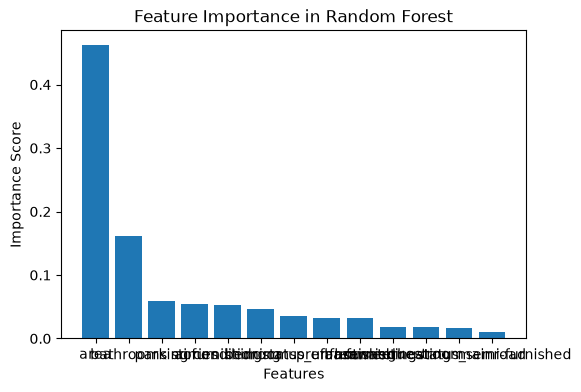

In [19]:
importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": model.feature_importances_
})

# Sort by importance
importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

# Plot feature importance

plt.figure(figsize=(6,4))

plt.bar(importance["Feature"], importance["Importance"])

plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Feature Importance in Random Forest")

plt.show()